In [ ]:
# Run this in a brand new Colab notebook
!pip install imbalanced-learn scikit-learn opencv-python scikit-image tqdm -q

import cv2
import numpy as np
import os
import pickle
import gc
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm

from skimage.feature import graycomatrix, graycoprops, local_binary_pattern, hog
from skimage.filters import gabor

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.feature_selection import f_classif

import warnings
warnings.filterwarnings('ignore')
print("All libraries loaded!")

All libraries loaded!


In [ ]:
from google.colab import files

# Upload your rim-one zip file
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile

# Change this to your exact zip filename
RIM_ZIP = "archive (1).zip"

with zipfile.ZipFile(RIM_ZIP, 'r') as z:
    z.extractall("rim_one_r12")
print("Extracted!")

# Verify structure
for root, dirs, files_list in os.walk("rim_one_r12"):
    level = root.replace("rim_one_r12", '').count(os.sep)
    if level < 4:
        print(' ' * 2 * level + os.path.basename(root) + '/')

Extracted!
rim_one_r12/
  RIM-ONE_DL_images/
    partitioned_randomly/
      training_set/
      test_set/
    partitioned_by_hospital/
      training_set/
      test_set/


In [ ]:
# Paths based on your confirmed folder structure
TRAIN_NORMAL   = "rim_one_r12/RIM-ONE_DL_images/partitioned_randomly/training_set/normal"
TRAIN_GLAUCOMA = "rim_one_r12/RIM-ONE_DL_images/partitioned_randomly/training_set/glaucoma"
TEST_NORMAL    = "rim_one_r12/RIM-ONE_DL_images/partitioned_randomly/test_set/normal"
TEST_GLAUCOMA  = "rim_one_r12/RIM-ONE_DL_images/partitioned_randomly/test_set/glaucoma"

IMG_SIZE = (224, 224)

def load_folder(folder_path, label):
    images, labels = [], []
    paths = []
    for ext in ['*.jpg','*.jpeg','*.png','*.bmp']:
        paths += glob(os.path.join(folder_path, ext))
        paths += glob(os.path.join(folder_path, '**', ext), recursive=True)
    paths = list(set(paths))
    print(f"  {len(paths)} images found in: {folder_path}")
    for fp in tqdm(paths, desc=label):
        img = cv2.imread(fp)
        if img is None:
            continue
        img = cv2.resize(img, IMG_SIZE)
        images.append(img)
        labels.append(label)
    return images, labels

# Load all images — combine train and test
# We do our own 10-fold CV so we need all images together
print("Loading images...")
imgs_n1, lbls_n1 = load_folder(TRAIN_NORMAL,   "Healthy")
imgs_n2, lbls_n2 = load_folder(TEST_NORMAL,    "Healthy")
imgs_g1, lbls_g1 = load_folder(TRAIN_GLAUCOMA, "Glaucoma")
imgs_g2, lbls_g2 = load_folder(TEST_GLAUCOMA,  "Glaucoma")

all_images = imgs_n1 + imgs_n2 + imgs_g1 + imgs_g2
all_labels = lbls_n1 + lbls_n2 + lbls_g1 + lbls_g2

print(f"\nTotal images loaded: {len(all_images)}")
print(f"  Healthy  : {all_labels.count('Healthy')}")
print(f"  Glaucoma : {all_labels.count('Glaucoma')}")

Loading images...
  219 images found in: rim_one_r12/RIM-ONE_DL_images/partitioned_randomly/training_set/normal


Healthy: 100%|██████████| 219/219 [00:02<00:00, 77.04it/s]


  94 images found in: rim_one_r12/RIM-ONE_DL_images/partitioned_randomly/test_set/normal


Healthy: 100%|██████████| 94/94 [00:01<00:00, 85.46it/s]


  120 images found in: rim_one_r12/RIM-ONE_DL_images/partitioned_randomly/training_set/glaucoma


Glaucoma: 100%|██████████| 120/120 [00:01<00:00, 62.29it/s]


  52 images found in: rim_one_r12/RIM-ONE_DL_images/partitioned_randomly/test_set/glaucoma


Glaucoma: 100%|██████████| 52/52 [00:00<00:00, 55.37it/s]


Total images loaded: 485
  Healthy  : 313
  Glaucoma : 172


In [ ]:
def augment_image(img):
    """
    Creates 3 extra versions of each image:
    1. Horizontal flip
    2. Vertical flip
    3. 90 degree rotation
    Returns: list of 3 augmented images
    """
    aug1 = cv2.flip(img, 1)          # horizontal flip
    aug2 = cv2.flip(img, 0)          # vertical flip
    aug3 = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)  # rotate 90
    return [aug1, aug2, aug3]

print("Augmenting dataset...")
augmented_images = []
augmented_labels = []

for img, lbl in tqdm(zip(all_images, all_labels),
                     total=len(all_images), desc="Augmenting"):
    # Keep original
    augmented_images.append(img)
    augmented_labels.append(lbl)
    # Add 3 augmented versions
    for aug in augment_image(img):
        augmented_images.append(aug)
        augmented_labels.append(lbl)

print(f"\nAfter augmentation:")
print(f"  Total images : {len(augmented_images)}")
print(f"  Healthy      : {augmented_labels.count('Healthy')}")
print(f"  Glaucoma     : {augmented_labels.count('Glaucoma')}")

# Free original images — no longer needed
del all_images
gc.collect()
print("RAM freed!")

Augmenting dataset...


Augmenting: 100%|██████████| 485/485 [00:00<00:00, 2778.18it/s]


After augmentation:
  Total images : 1940
  Healthy      : 1252
  Glaucoma     : 688


RAM freed!


In [ ]:
# ================================================
# ALL FEATURE FUNCTIONS — run this entire cell
# ================================================

def preprocess_image(img):
    """Green channel + denoise + CLAHE + sharpen"""
    green    = img[:, :, 1]
    denoised = cv2.fastNlMeansDenoising(green, h=10)
    clahe    = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)
    kernel   = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    sharpened = cv2.filter2D(enhanced, -1, kernel)
    return sharpened


def crop_optic_disc(img, size=80):
    """
    Crop the optic disc region from fundus image.
    Optic disc sits at roughly 60% from left, center height.
    """
    h, w   = img.shape
    cx, cy = int(w * 0.60), int(h * 0.50)
    half   = size // 2
    x1, x2 = max(0, cx-half), min(w, cx+half)
    y1, y2 = max(0, cy-half), min(h, cy+half)
    crop   = img[y1:y2, x1:x2]
    if crop.shape[0] > 0 and crop.shape[1] > 0:
        return cv2.resize(crop, (size, size))
    return cv2.resize(img, (size, size))


def glcm_features(img):
    """GLCM texture: energy, contrast, homogeneity, correlation, dissimilarity"""
    u8 = (img*255).astype(np.uint8) if img.max()<=1.0 else img.astype(np.uint8)
    r  = (u8 // 4).astype(np.uint8)
    g  = graycomatrix(r, distances=[1,2,3],
                      angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                      levels=64, symmetric=True, normed=True)
    feats = []
    for p in ['energy','contrast','homogeneity','correlation','dissimilarity']:
        feats += [graycoprops(g, p).mean(), graycoprops(g, p).std()]
    return feats  # 10 features


def entropy_features(img):
    """Shannon, Renyi, Kapur, Yager entropy"""
    u8    = (img*255).astype(np.uint8) if img.max()<=1.0 else img.astype(np.uint8)
    flat  = u8.flatten()
    hist, _ = np.histogram(flat, bins=256, range=(0,256))
    px    = hist / (len(flat) + 1e-10)
    px    = px[px > 0]
    shan  = -np.sum(px * np.log2(px + 1e-10))
    reny  = (1/(1-2)) * np.log2(np.sum(px**2) + 1e-10)
    kapu  = (1/1.5) * np.log2((np.sum(px**0.5)/(np.sum(px**2)+1e-10))+1e-10)
    yage  = 1 - np.sum(np.abs(2*px-1)) / len(flat)
    return [shan, reny, kapu, yage]  # 4 features


def lbp_features(img):
    """Local binary pattern histogram — captures micro-textures"""
    u8   = (img*255).astype(np.uint8) if img.max()<=1.0 else img.astype(np.uint8)
    lbp  = local_binary_pattern(u8, P=24, R=3, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=26, range=(0,26), density=True)
    return hist.tolist()  # 26 features


def hog_features(img):
    """HOG gradient features — captures optic disc shape"""
    u8   = (img*255).astype(np.uint8) if img.max()<=1.0 else img.astype(np.uint8)
    res  = cv2.resize(u8, (64, 64))
    h    = hog(res, orientations=9, pixels_per_cell=(8,8),
               cells_per_block=(2,2), visualize=False)
    step = len(h) // 36
    return [np.mean(h[i:i+step]) for i in range(0, 36*step, step)][:36]  # 36 features


def gabor_features(img):
    """Gabor filter — captures oriented nerve fiber textures"""
    f = img.astype(np.float32) if img.max()<=1.0 else img.astype(np.float32)/255.0
    feats = []
    for freq in [0.1, 0.3, 0.5]:
        for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
            real, _ = gabor(f, frequency=freq, theta=theta)
            feats  += [real.mean(), real.std()]
    return feats  # 24 features


def extract_one_image(processed_img):
    """
    Full feature vector for ONE image:
    - 4 IMF layers × (10 GLCM + 4 entropy + 26 LBP + 36 HOG) = 304
    - Full image: + 24 Gabor = 100
    - Optic disc crop: 10+4+26+36+24 = 100
    Total: ~504 features
    """
    all_feats = []

    # IEMD decomposition into 3 IMFs + residue
    img_f   = processed_img.astype(np.float32) / 255.0
    residue = img_f.copy()
    imfs    = []
    for i in range(3):
        smooth = cv2.GaussianBlur(residue, (15,15), 2*(i+1))
        imfs.append(residue - smooth)
        residue = smooth
    imfs.append(residue)

    # Features from each IMF
    for imf in imfs:
        n = np.clip(imf, 0, None)
        mx = n.max()
        if mx > 0:
            n = n / mx
        all_feats += glcm_features(n)
        all_feats += entropy_features(n)
        all_feats += lbp_features(n)
        all_feats += hog_features(n)

    # Features from full preprocessed image
    norm = processed_img.astype(np.float32) / 255.0
    all_feats += glcm_features(norm)
    all_feats += entropy_features(norm)
    all_feats += lbp_features(norm)
    all_feats += hog_features(norm)
    all_feats += gabor_features(norm)

    # Features from optic disc crop
    disc = crop_optic_disc(processed_img).astype(np.float32) / 255.0
    all_feats += glcm_features(disc)
    all_feats += entropy_features(disc)
    all_feats += lbp_features(disc)
    all_feats += hog_features(disc)
    all_feats += gabor_features(disc)

    return all_feats

print("All feature functions defined!")

All feature functions defined!


In [ ]:
print(f"Preprocessing {len(augmented_images)} images...")
processed_images = []

for img in tqdm(augmented_images, desc="Preprocessing"):
    processed_images.append(preprocess_image(img))

del augmented_images
gc.collect()
print("Preprocessing done! RAM freed.")

Preprocessing 1940 images...


Preprocessing: 100%|██████████| 1940/1940 [02:42<00:00, 11.97it/s]


Preprocessing done! RAM freed.


In [ ]:
print(f"Extracting features from {len(processed_images)} images...")
print("This takes ~20-30 mins. Progress bar shows status.\n")

X_all = []
for img in tqdm(processed_images, desc="Feature extraction"):
    feats = extract_one_image(img)
    X_all.append(feats)

X_all = np.array(X_all)
y_all = np.array(augmented_labels)

print(f"\nFeature matrix shape: {X_all.shape}")
print(f"Labels: {np.unique(y_all, return_counts=True)}")

# Save immediately — critical!
np.save("X_all.npy", X_all)
np.save("y_all.npy", y_all)
print("\nFeatures saved to disk!")

del processed_images
gc.collect()

Extracting features from 1940 images...
This takes ~20-30 mins. Progress bar shows status.



Feature extraction: 100%|██████████| 1940/1940 [50:09<00:00,  1.55s/it]



Feature matrix shape: (1940, 504)
Labels: (array(['Glaucoma', 'Healthy'], dtype='<U8'), array([ 688, 1252]))

Features saved to disk!


0

In [ ]:
print("Normalizing features...")
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_all)
print(f"Scaled — mean: {X_scaled.mean():.4f}, std: {X_scaled.std():.4f}")

Normalizing features...
Scaled — mean: 0.0000, std: 1.0000


In [ ]:
print("Running ANOVA feature ranking...")
le    = LabelEncoder()
y_enc = le.fit_transform(y_all)

f_scores, p_vals  = f_classif(X_scaled, y_enc)
ranked_idx        = np.argsort(f_scores)[::-1]

# Keep top 100 features
TOP_K     = 100
X_top     = X_scaled[:, ranked_idx[:TOP_K]]

print(f"Top {TOP_K} features selected from {X_scaled.shape[1]} total")
print(f"Top 5 F-scores: {f_scores[ranked_idx[:5]].round(2)}")

Running ANOVA feature ranking...
Top 100 features selected from 504 total
Top 5 F-scores: [553.5  435.5  411.49 403.36 401.32]


In [ ]:
print("Applying PCA...")
N_COMPONENTS = 40
pca   = PCA(n_components=N_COMPONENTS)
X_pca = pca.fit_transform(X_top)

explained = sum(pca.explained_variance_ratio_) * 100
print(f"PCA: {N_COMPONENTS} components explain {explained:.1f}% of variance")
print(f"Final feature shape: {X_pca.shape}")

Applying PCA...
PCA: 40 components explain 94.7% of variance
Final feature shape: (1940, 40)


In [ ]:
print("Running GridSearch to find best SVM parameters...")
print("This takes ~3-5 minutes...\n")

param_grid = {
    'C'    : [10, 50, 100, 200],
    'gamma': ['scale', 0.01, 0.001]
}

base_svm = SVC(kernel='rbf', probability=True, class_weight='balanced')
grid     = GridSearchCV(base_svm, param_grid,
                        cv=3, scoring='accuracy',
                        n_jobs=-1, verbose=1)
grid.fit(X_pca, y_enc)

best_C     = grid.best_params_['C']
best_gamma = grid.best_params_['gamma']
print(f"\nBest params: C={best_C}, gamma={best_gamma}")
print(f"Best CV accuracy: {grid.best_score_*100:.2f}%")

Running GridSearch to find best SVM parameters...
This takes ~3-5 minutes...

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best params: C=10, gamma=0.001
Best CV accuracy: 82.94%


In [ ]:
print("\nTraining ensemble model with 10-fold cross-validation...")
print("SVM + Random Forest + Gradient Boosting voting together\n")

# Build 3 strong models
svm_model = SVC(kernel='rbf', C=best_C, gamma=best_gamma,
                probability=True, class_weight='balanced')

rf_model  = RandomForestClassifier(
                n_estimators=300,
                max_depth=20,
                min_samples_split=3,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1)

gb_model  = GradientBoostingClassifier(
                n_estimators=150,
                learning_rate=0.08,
                max_depth=5,
                subsample=0.8,
                random_state=42)

# Ensemble — soft voting averages probabilities from all 3
ensemble  = VotingClassifier(
                estimators=[
                    ('svm', svm_model),
                    ('rf',  rf_model),
                    ('gb',  gb_model)
                ],
                voting='soft')

# 10-fold CV
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

all_acc, all_sen, all_spc = [], [], []
all_true, all_pred        = [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_pca, y_enc), 1):
    X_train, X_test = X_pca[train_idx], X_pca[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]

    ensemble.fit(X_train, y_train)
    y_pred = ensemble.predict(X_test)

    all_true.extend(y_test)
    all_pred.extend(y_pred)

    acc = accuracy_score(y_test, y_pred) * 100
    cm  = confusion_matrix(y_test, y_pred)

    # Binary: Glaucoma=0, Healthy=1
    tp = cm[0,0]; fn = cm[0,1]
    fp = cm[1,0]; tn = cm[1,1]
    sen = tp/(tp+fn+1e-8) * 100
    spc = tn/(tn+fp+1e-8) * 100

    all_acc.append(acc)
    all_sen.append(sen)
    all_spc.append(spc)

    print(f"  Fold {fold:2d} | Acc: {acc:.2f}%  Sen: {sen:.2f}%  Spc: {spc:.2f}%")

print(f"\n{'='*52}")
print(f"  FINAL RESULTS — RIM-ONE r12 Binary")
print(f"{'='*52}")
print(f"  Accuracy    : {np.mean(all_acc):.2f}% ± {np.std(all_acc):.2f}%")
print(f"  Sensitivity : {np.mean(all_sen):.2f}% ± {np.std(all_sen):.2f}%")
print(f"  Specificity : {np.mean(all_spc):.2f}% ± {np.std(all_spc):.2f}%")
print(f"{'='*52}")


Training ensemble model with 10-fold cross-validation...
SVM + Random Forest + Gradient Boosting voting together

  Fold  1 | Acc: 89.69%  Sen: 79.41%  Spc: 95.24%
  Fold  2 | Acc: 89.18%  Sen: 79.41%  Spc: 94.44%
  Fold  3 | Acc: 89.18%  Sen: 76.81%  Spc: 96.00%
  Fold  4 | Acc: 87.11%  Sen: 72.46%  Spc: 95.20%
  Fold  5 | Acc: 91.24%  Sen: 79.71%  Spc: 97.60%
  Fold  6 | Acc: 88.66%  Sen: 84.06%  Spc: 91.20%
  Fold  7 | Acc: 91.24%  Sen: 85.51%  Spc: 94.40%
  Fold  8 | Acc: 87.63%  Sen: 76.81%  Spc: 93.60%
  Fold  9 | Acc: 89.69%  Sen: 81.16%  Spc: 94.40%
  Fold 10 | Acc: 90.72%  Sen: 79.71%  Spc: 96.80%

  FINAL RESULTS — RIM-ONE r12 Binary
  Accuracy    : 89.43% ± 1.33%
  Sensitivity : 79.51% ± 3.52%
  Specificity : 94.89% ± 1.69%


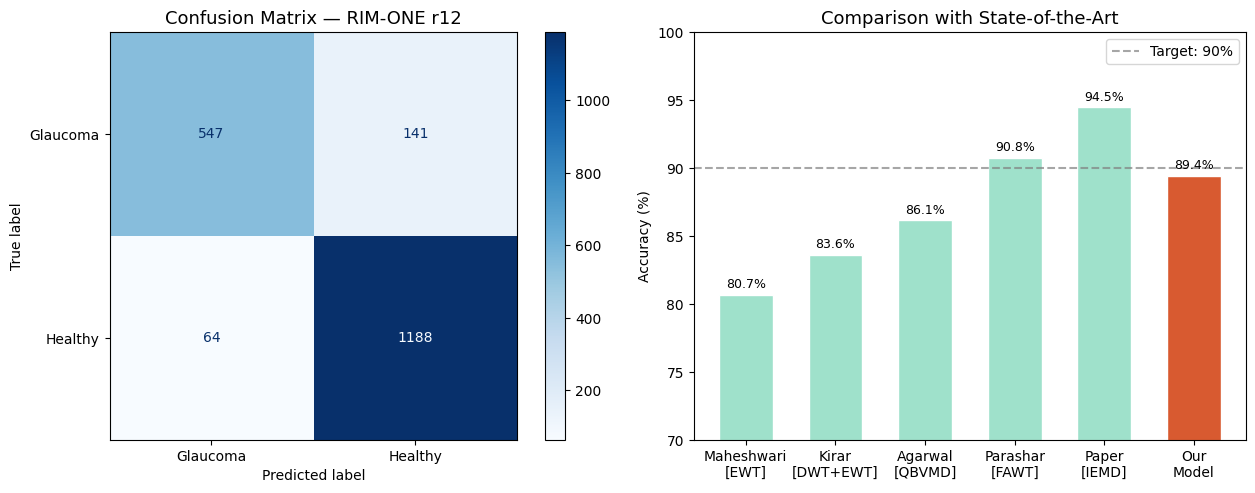


Classification Report:
              precision    recall  f1-score   support

    Glaucoma       0.90      0.80      0.84       688
     Healthy       0.89      0.95      0.92      1252

    accuracy                           0.89      1940
   macro avg       0.89      0.87      0.88      1940
weighted avg       0.89      0.89      0.89      1940



In [ ]:
# Confusion matrix
all_true = np.array(all_true)
all_pred = np.array(all_pred)

cm   = confusion_matrix(all_true, all_pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=le.classes_)
disp.plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title("Confusion Matrix — RIM-ONE r12", fontsize=13)

# Plot 2: Comparison bar chart with paper results
methods = ['Maheshwari\n[EWT]', 'Kirar\n[DWT+EWT]',
           'Agarwal\n[QBVMD]', 'Parashar\n[FAWT]',
           'Paper\n[IEMD]', 'Our\nModel']
accs    = [80.66, 83.60, 86.13, 90.76, 94.45, np.mean(all_acc)]
colors  = ['#9FE1CB']*5 + ['#D85A30']

bars = axes[1].bar(methods, accs, color=colors, edgecolor='white', width=0.6)
axes[1].axhline(y=90, color='gray', linestyle='--', alpha=0.7, label='Target: 90%')
axes[1].set_ylim(70, 100)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Comparison with State-of-the-Art', fontsize=13)
axes[1].legend()

for bar, val in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("results.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(all_true, all_pred, target_names=le.classes_))

In [ ]:
print("Retraining final model on ALL data...")
ensemble.fit(X_pca, y_enc)
print("Final model trained!")

# Save everything needed for prediction
model_bundle = {
    'model'               : ensemble,
    'scaler'              : scaler,
    'pca'                 : pca,
    'label_encoder'       : le,
    'top_feature_indices' : ranked_idx[:TOP_K],
    'best_accuracy'       : np.mean(all_acc),
    'n_pca_components'    : N_COMPONENTS
}

with open("glaucoma_final_model.pkl", "wb") as f:
    pickle.dump(model_bundle, f)
print("Model saved: glaucoma_final_model.pkl")

Retraining final model on ALL data...
Final model trained!
Model saved: glaucoma_final_model.pkl


In [ ]:
# Download model
from google.colab import files
files.download("glaucoma_final_model.pkl")
files.download("results.png")
files.download("X_all.npy")
files.download("y_all.npy")
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!


In [ ]:
# ================================================
# PREDICT ON A NEW IMAGE
# ================================================
def predict_new_image(image_path, model_path="glaucoma_final_model.pkl"):
    with open(model_path, 'rb') as f:
        bundle = pickle.load(f)

    model    = bundle['model']
    scaler   = bundle['scaler']
    pca      = bundle['pca']
    le       = bundle['label_encoder']
    top_idx  = bundle['top_feature_indices']

    # Load and process
    img      = cv2.imread(image_path)
    img      = cv2.resize(img, (224, 224))
    proc     = preprocess_image(img)

    # Extract features
    feats    = np.array(extract_one_image(proc)).reshape(1, -1)
    scaled   = scaler.transform(feats)
    top      = scaled[:, top_idx]
    reduced  = pca.transform(top)

    # Predict
    pred     = model.predict(reduced)[0]
    probs    = model.predict_proba(reduced)[0]
    label    = le.inverse_transform([pred])[0]

    print(f"\nPrediction : {label}")
    for cls, prob in zip(le.classes_, probs):
        bar = "█" * int(prob * 30)
        print(f"  {cls:<10} {prob*100:5.1f}%  {bar}")
    return label

# Usage:
# predict_new_image("path/to/your/fundus_image.jpg")